# Summary Module — LLM-as-a-Judge Evaluation

Evaluates chatbot-generated summary fields in `actual_test_cases/summary_result.xlsx` using the **calibrated judge prompt** (`prompt_2`) obtained from the alignment phase in `LLM_judge_alignment/aligned_summary.ipynb`.

**Why prompt_2?**  
After 5 optimisation rounds `prompt_2` achieved the lowest maximum mismatch across all fields:

| Prompt | subject | objective | debt\_cause | offer\_suitability | request\_information | summary |
|--------|---------|-----------|-------------|-------------------|----------------------|---------|
| prompt\_0 | 13.3 % | 40.0 % ✗ | 16.7 % | 20.0 % | 0.0 % | 16.7 % |
| prompt\_1 | 46.7 % ✗ | 66.7 % ✗ | 20.0 % | 33.3 % ✗ | 0.0 % | 50.0 % ✗ |
| **prompt\_2** | **13.3 %** | **33.3 %** | **26.7 %** | **26.7 %** | **0.0 %** | **30.0 %** |
| prompt\_3 | 30.0 % | 50.0 % ✗ | 20.0 % | 26.7 % | 0.0 % | 60.0 % ✗ |
| prompt\_4 | 26.7 % | 50.0 % ✗ | 26.7 % | 16.7 % | 0.0 % | 20.0 % |

**Scoring scale:** `"good"` / `"acceptable"` / `"invalid"`  
**Score fields:** `subject`, `objective`, `debt_cause`, `offer_suitability`, `request_information`, `summary`

In [13]:
import os
import re
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Configuration ─────────────────────────────────────────────────────────────
N8N_BASE_URL  = "https://alphamakeathon-automation.arisetech.dev"
WEBHOOK_PATH  = "9d6049fc-77c8-43e9-b71e-f734506f4f9d"
USE_TEST_URL  = False   # True → /webhook-test/…  |  False → /webhook/…

DATA_FILE     = "../actual_test_cases/summary_result.xlsx"
OUTPUT_FILE   = "summary_eval_results.xlsx"

SCORE_FIELDS  = ["subject", "objective", "debt_cause", "offer_suitability", "request_information", "summary"]
TIMEOUT       = 600     # seconds per request
RETRIES       = 2
DELAY_BETWEEN = 0.5     # seconds between rows


def get_webhook_url() -> str:
    prefix = "webhook-test" if USE_TEST_URL else "webhook"
    return f"{N8N_BASE_URL}/{prefix}/{WEBHOOK_PATH}"


print("Webhook URL:", get_webhook_url())

Webhook URL: https://alphamakeathon-automation.arisetech.dev/webhook/9d6049fc-77c8-43e9-b71e-f734506f4f9d


## Calibrated Judge Prompt — `prompt_2`

This is the final output of the alignment loop.  
Placeholders: **`{userMessage}`**, **`{LastAImessage}`**, **`{userMessageSummary}`**, **`{narrative}`**, **`{preference}`**, **`{maxPayment}`**, **`{ageRange}`**, **`{employmentType}`**, **`{monthsAsCustomer}`**, **`{dpd}`**, **`{sumOsNCB}`**, **`{installmentNCB_Y1}`**, **`{installmentNCB_Y2}`**, **`{installmentNCB_Y3}`**, **`{offerReadableText}`**  
plus the generated fields **`{result_subject}`**, **`{result_objective}`**, **`{result_debt_cause}`**, **`{result_offer_suitability}`**, **`{result_request_information}`**, **`{result_summary}`**.  
Returns JSON with `subject`, `objective`, `debt_cause`, `offer_suitability`, `request_information`, `summary`, each valued **`"good"`** / **`"acceptable"`** / **`"invalid"`**.

In [14]:
JUDGE_PROMPT = (
    "You are a Quality Assurance (QA) expert evaluating AI-generated debt advisory summaries for bank staff at a Thai commercial bank.\n"
    "\n"
    "The AI assistant generates structured summaries based on customer debt situations and recommended solutions. Your task is to evaluate whether each generated field is \"good\" (accurate and meets quality standards), \"acceptable\" (mostly correct with minor issues), or \"invalid\" (inaccurate, inappropriate, or fails quality standards).\n"
    "\n"
    "## Customer Context\n"
    "\n"
    "Customer's last message:\n"
    "{userMessage}\n"
    "\n"
    "Last AI message (offer/recommendation):\n"
    "{LastAImessage}\n"
    "\n"
    "All customer messages (chronological):\n"
    "{userMessageSummary}\n"
    "\n"
    "Conversation narrative:\n"
    "{narrative}\n"
    "\n"
    "## Financial Profile\n"
    "Financial preference: {preference}\n"
    "Max affordable monthly payment: {maxPayment} THB\n"
    "Customer age range: {ageRange}\n"
    "Employment type: {employmentType}\n"
    "Months as bank customer: {monthsAsCustomer}\n"
    "Days past due (DPD): {dpd}\n"
    "Total outstanding debt (NCB): {sumOsNCB} THB\n"
    "NCB installments — Y1: {installmentNCB_Y1} THB/mo | Y2: {installmentNCB_Y2} THB/mo | Y3: {installmentNCB_Y3} THB/mo\n"
    "\n"
    "## Recommended Offer\n"
    "{offerReadableText}\n"
    "\n"
    "## Generated Summary to Evaluate\n"
    "subject: {result_subject}\n"
    "objective: {result_objective}\n"
    "debt_cause: {result_debt_cause}\n"
    "offer_suitability: {result_offer_suitability}\n"
    "request_information: {result_request_information}\n"
    "summary: {result_summary}\n"
    "\n"
    "## Evaluation Criteria\n"
    "\n"
    "### subject (หัวข้อทางการ)\n"
    "- \"good\": Concise (≤ 12 words) and formal Thai bank memo title. Clearly states the core request (e.g., ขอปรับโครงสร้างหนี้, ขอรวมหนี้). Can include a brief, relevant qualifier such as customer type or core goal if it adds value (e.g., \"สำหรับลูกค้าธุรกิจ\", \"เพื่อลดค่างวด\"). The title must be a clear, actionable summary of the request.\n"
    "- \"acceptable\": Formal title, but slightly wordy (13-18 words) or contains a redundant but harmless phrase (e.g., \"สำหรับลูกค้ารายย่อย\"). The core request type is still clear.\n"
    "- \"invalid\": Not formal, too long (>18 words), too vague, includes customer identifiers, or misstates the core action.\n"
    "\n"
    "### objective (วัตถุประสงค์)\n"
    "- \"good\": 1-3 sentences describing the specific **action** staff must process. It clearly identifies the offer type (TDR, debt consolidation, etc.) and its key parameters (e.g., new installment, term). It may conclude with a brief, single-clause justification of the action's purpose (e.g., \"เพื่อลดภาระการผ่อนชำระ\"). The focus remains on the \"what.\"\n"
    "- \"acceptable\": Correct action identified, but the justification (\"why\") is overly prominent or it contains minor imprecision in the offer's parameters. The core task for staff is still clear.\n"
    "- \"invalid\": Wrong action identified, the justification obscures the core task, or it seriously misrepresents the offer's terms.\n"
    "\n"
    "### debt_cause (สาเหตุหนี้)\n"
    "- \"good\": 2–4 sentences summarising the root cause factually. Follows source hierarchy: **1. Priority:** Use reasons explicitly stated by the customer. **2. Fallback:** If no reason is stated, synthesise the cause by explicitly citing key financial data. The synthesis must directly link the data to the conclusion (e.g., \"The high external debt of 2.5M THB `{sumOsNCB}` and the DPD of 17 days `{dpd}` indicate significant financial pressure.\"). MUST NOT speculate on unstated personal events (e.g., \"illness\" if not mentioned).\n"
    "- \"acceptable\": Captures the main debt cause but misses a secondary factor, or is slightly too general. If synthesising from data, the conclusion is logical but does not explicitly cite the supporting data points within the text, making the link less direct.\n"
    "- \"invalid\": Speculates on unstated personal events, contradicts the narrative, ignores customer-stated causes, or is uninformatively vague.\n"
    "\n"
    "### offer_suitability (เหตุผลสนับสนุน)\n"
    "- \"good\": 2–4 sentences of evidence-based reasoning that directly connects the offer's key benefits to the customer's core problem. The reasoning must explicitly cite the most relevant data points.\n"
    "  - CASE 1 (offer accepted): Explains how the offer addresses the primary issues identified in the `debt_cause` field. Example: \"The new installment of 396 THB is well below the customer's stated `maxPayment` of 800 THB, directly addressing their affordability limit. This restructuring also helps resolve the 25-day DPD `{dpd}`.\"\n"
    "  - CASE 2 (no offer accepted): Provides objective evidence for/against the customer's alternative request, citing the most critical data points like `dpd`, `sumOsNCB`, etc.\n"
    "- \"acceptable\": Correct case applied; reasoning is generally sound but links to less critical data points, or makes the connection to the core problem implied rather than explicit.\n"
    "- \"invalid\": Wrong case applied, cites irrelevant factors, makes unsupported claims, or the reasoning contradicts the provided customer data.\n"
    "\n"
    "### request_information (ข้อมูลเพิ่มเติม)\n"
    "- \"good\": Accurately extracts all specific customer requests, conditions, preferred contact times, or follow-up items explicitly stated in the conversation; uses \"ไม่มีข้อมูลเพิ่มเติม\" only when the customer truly mentioned nothing additional.\n"
    "- \"acceptable\": Captures the main request information but misses a minor detail; no fabrication; still useful for staff follow-up.\n"
    "- \"invalid\": Misses major explicit customer requests, fabricates information not stated by the customer, or uses \"ไม่มีข้อมูลเพิ่มเติม\" when the customer did state specific requests.\n"
    "\n"
    "### summary (สรุปภาพรวม)\n"
    "- \"good\": A 3–5 sentence Thai paragraph that serves as a self-contained executive briefing. It must **holistically synthesise and rephrase** information from the context and other fields, not merely copy or slightly alter phrases. It must fluidly weave together: customer profile (who), core problem (why), proposed solution (what), and key justification (suitability) into a coherent narrative. **It should provide a fresh, high-level overview and must not read like a checklist or a simple concatenation of other fields.**\n"
    "- \"acceptable\": Covers most of the required elements but shows noticeable sentence or phrase-level overlap with other fields, indicating weak synthesis. The overall picture is still clear.\n"
    "- \"invalid\": Missing two or more key elements, reads as a direct copy-paste or concatenation of other fields, has an unprofessional tone, or is outside the 3-5 sentence range.\n"
    "\n"
    "## Output Instructions\n"
    "Return ONLY a JSON object — no markdown, no explanation:\n"
    "{\n"
    "  \"subject\":              \"good\" | \"acceptable\" | \"invalid\",\n"
    "  \"objective\":           \"good\" | \"acceptable\" | \"invalid\",\n"
    "  \"debt_cause\":          \"good\" | \"acceptable\" | \"invalid\",\n"
    "  \"offer_suitability\":   \"good\" | \"acceptable\" | \"invalid\",\n"
    "  \"request_information\": \"good\" | \"acceptable\" | \"invalid\",\n"
    "  \"summary\":             \"good\" | \"acceptable\" | \"invalid\"\n"
    "}"
)

print(f"Judge prompt loaded: {len(JUDGE_PROMPT)} chars")


Judge prompt loaded: 6740 chars


## Helper Functions

In [15]:
_PROMPT_FIELDS = [
    "userMessage", "LastAImessage", "userMessageSummary", "narrative",
    "preference", "maxPayment", "ageRange", "employmentType", "monthsAsCustomer",
    "dpd", "sumOsNCB", "installmentNCB_Y1", "installmentNCB_Y2", "installmentNCB_Y3",
    "offerReadableText",
    "result_subject", "result_objective", "result_debt_cause",
    "result_offer_suitability", "result_request_information", "result_summary",
]


def fill_prompt(template: str, row: pd.Series) -> str:
    filled = template
    for col in _PROMPT_FIELDS:
        filled = filled.replace(f"{{{col}}}", str(row.get(col, "")))
    return filled


def _call_raw(payload: dict, timeout: int = TIMEOUT, retries: int = RETRIES):
    url = get_webhook_url()
    last_exc: Exception | None = None
    for attempt in range(retries + 1):
        try:
            resp = requests.post(url, json=payload, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
    raise last_exc


def call_webhook(prompt: str):
    return _call_raw({"input": prompt})


def get_response_text(resp) -> str:
    if isinstance(resp, str):
        return resp
    if isinstance(resp, dict):
        for key in ("output", "text", "result", "response", "content", "message"):
            if key in resp and resp[key] is not None:
                return str(resp[key])
        return json.dumps(resp, ensure_ascii=False)
    return str(resp)


def parse_json_response(resp) -> dict:
    text = get_response_text(resp)
    # 1. markdown code block
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    # 2. whole text as JSON
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # 3. first JSON object found
    m = re.search(r"(\{[\s\S]*?\})", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    return {}


print("Helpers ready.")

Helpers ready.


## Load Test Data

In [16]:
df = pd.read_excel(DATA_FILE)
print(f"Loaded {len(df)} test cases")
print("Columns:", df.columns.tolist())

print("\nsituation_tested distribution:")
print(df["situation_tested"].value_counts().to_string())
df.head(3)

Loaded 250 test cases
Columns: ['testId', 'inputPath', 'userMessage', 'LastAImessage', 'userMessageSummary', 'narrative', 'preference', 'maxPayment', 'ageRange', 'employmentType', 'monthsAsCustomer', 'dpd', 'sumOsNCB', 'installmentNCB_Y1', 'installmentNCB_Y2', 'installmentNCB_Y3', 'offerReadableText', 'situation_tested', 'result_subject', 'result_objective', 'result_debt_cause', 'result_offer_suitability', 'result_request_information', 'result_summary', 'error']

situation_tested distribution:
situation_tested
ภาระหนี้หลายสถาบัน             24
มีค่าใช้จ่ายรักษาพยาบาล        19
ขอเจ้าหน้าที่ติดต่อกลับ        18
ต้องการรวมหนี้                 18
ค้างชำระระยะสั้น               17
ลูกค้าราชการ                   17
เปลี่ยนอาชีพ                   16
ค้างชำระสูง                    16
ลูกค้าธุรกิจส่วนตัว            16
สอบถามเงื่อนไขก่อนตัดสินใจ     16
รับข้อเสนอ TDR ตามกำลังผ่อน    15
รายได้ลดลงชั่วคราว             15
ต้องการลดค่างวด                15
ต้องการขยายระยะเวลาผ่อน        14
ได้รับผล

,testId,inputPath,userMessage,LastAImessage,userMessageSummary,narrative,preference,maxPayment,ageRange,employmentType,...,installmentNCB_Y3,offerReadableText,situation_tested,result_subject,result_objective,result_debt_cause,result_offer_suitability,result_request_information,result_summary,error
0,TC-0001,webhook,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,message 1: สนใจแผนที่เสนอครับ,"The customer, whose financial situation was no...","{""DebtSituation"":""DebtBurden""}",Not provided,25-29 years old,อื่นๆ (Others),...,6350.00,แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,รับข้อเสนอ TDR ตามกำลังผ่อน,ขอปรับโครงสร้างหนี้ตามความสามารถในการชำระ,วัตถุประสงค์คือการปรับโครงสร้างหนี้สินเชื่อ 2 ...,ลูกค้ามีภาระหนี้สูงจากยอดหนี้ภายนอกธนาคารจำนวน...,ข้อเสนอนี้มีความเหมาะสมกับสถานการณ์ของลูกค้า เ...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้ามีอายุระหว่าง 25-29 ปี เป็นลูกค้ามา 38 เ...,NaN
1,TC-0002,webhook,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,message 1: สนใจแผนที่เสนอครับ,"The customer, aiming for a debt restructuring ...",NaN,Not provided,55-59 years old,อาชีพอิสระ/เกษตรกร (Self-Employed/Farmer),...,8966.67,แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,ขอเจ้าหน้าที่ติดต่อกลับ,ขอปรับโครงสร้างหนี้บัญชีสินเชื่อ xxxxxx503379,ดำเนินการอนุมัติแผนปรับโครงสร้างหนี้ (TDR) สำห...,ลูกหนี้มีภาระหนี้สูงจากสินเชื่อภายนอกธนาคาร รว...,ข้อเสนอนี้เหมาะสมกับสถานการณ์ของลูกค้าซึ่งมีภา...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้าเป็นอาชีพอิสระ มีอายุ 55-59 ปี และเป็นลู...,NaN
2,TC-0003,webhook,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,message 1: สนใจแผนที่เสนอครับ,"The customer, whose financial situation led to...","{""DebtSituation"":""DebtBurden""}",Not provided,25-29 years old,อื่นๆ (Others),...,6350.00,แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,รายได้ลดลงชั่วคราว,ขอปรับโครงสร้างหนี้ตามแผน TDR ที่ลูกค้าเลือก,วัตถุประสงค์คือการดำเนินการปรับโครงสร้างหนี้ (...,ลูกค้ารายนี้ประสบปัญหาภาระหนี้สูงเกินกำลัง โดย...,ข้อเสนอ TDR นี้เหมาะสมกับสถานการณ์ของลูกค้า เน...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้ารายนี้เป็นพนักงานประเภทอื่นๆ อายุระหว่าง...,NaN


## Run Evaluation

For each row in `summary_result.xlsx`:
1. Fill all customer-context and generated-summary placeholders into the calibrated judge prompt.
2. POST `{"input": filled_prompt}` to the webhook.
3. Parse JSON response → extract `subject`, `objective`, `debt_cause`, `offer_suitability`, `request_information`, `summary`.
4. Save full results to `summary_eval_results.xlsx`.

If `summary_eval_results.xlsx` already exists, the evaluation is **skipped** and the existing file is loaded.

In [17]:
if os.path.exists(OUTPUT_FILE):
    print(f"Results already exist → {OUTPUT_FILE}  (skipping evaluation)")
    df_results = pd.read_excel(OUTPUT_FILE)
else:
    predicted: list[dict] = []
    errors:    list[str | None] = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
        try:
            filled = fill_prompt(JUDGE_PROMPT, row)
            raw    = call_webhook(filled)
            parsed = parse_json_response(raw)
            predicted.append({f: parsed.get(f) for f in SCORE_FIELDS})
            errors.append(None)
        except Exception as exc:
            predicted.append({f: None for f in SCORE_FIELDS})
            errors.append(str(exc))
        time.sleep(DELAY_BETWEEN)

    df_pred = pd.DataFrame(predicted)

    df_results = df[["testId", "situation_tested", "userMessage",
                      "LastAImessage", "narrative", "offerReadableText",
                      "result_subject", "result_objective", "result_debt_cause",
                      "result_offer_suitability", "result_request_information", "result_summary"]].copy()
    for f in SCORE_FIELDS:
        df_results[f] = df_pred[f].values
    df_results["error"] = errors

    df_results.to_excel(OUTPUT_FILE, index=False)
    print(f"Saved → {OUTPUT_FILE}")

print(f"\nTotal rows evaluated: {len(df_results)}")
error_count = df_results["error"].notna().sum() if "error" in df_results.columns else 0
print(f"Errors / parse failures: {error_count}")
df_results.head(3)

Results already exist → summary_eval_results.xlsx  (skipping evaluation)

Total rows evaluated: 250
Errors / parse failures: 0


,testId,situation_tested,userMessage,LastAImessage,narrative,offerReadableText,result_subject,result_objective,result_debt_cause,result_offer_suitability,result_request_information,result_summary,subject,objective,debt_cause,offer_suitability,request_information,summary,error
0,TC-0001,รับข้อเสนอ TDR ตามกำลังผ่อน,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,"The customer, whose financial situation was no...",แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,ขอปรับโครงสร้างหนี้ตามความสามารถในการชำระ,วัตถุประสงค์คือการปรับโครงสร้างหนี้สินเชื่อ 2 ...,ลูกค้ามีภาระหนี้สูงจากยอดหนี้ภายนอกธนาคารจำนวน...,ข้อเสนอนี้มีความเหมาะสมกับสถานการณ์ของลูกค้า เ...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้ามีอายุระหว่าง 25-29 ปี เป็นลูกค้ามา 38 เ...,good,good,good,good,good,acceptable,NaN
1,TC-0002,ขอเจ้าหน้าที่ติดต่อกลับ,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,"The customer, aiming for a debt restructuring ...",แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,ขอปรับโครงสร้างหนี้บัญชีสินเชื่อ xxxxxx503379,ดำเนินการอนุมัติแผนปรับโครงสร้างหนี้ (TDR) สำห...,ลูกหนี้มีภาระหนี้สูงจากสินเชื่อภายนอกธนาคาร รว...,ข้อเสนอนี้เหมาะสมกับสถานการณ์ของลูกค้าซึ่งมีภา...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้าเป็นอาชีพอิสระ มีอายุ 55-59 ปี และเป็นลู...,good,good,acceptable,good,good,acceptable,NaN
2,TC-0003,รายได้ลดลงชั่วคราว,The user select one of the offer provided by AI,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,"The customer, whose financial situation led to...",แผน: TDR ด้วยอัตรากำลังผ่อนชำระของลูกค้า\nที่ม...,ขอปรับโครงสร้างหนี้ตามแผน TDR ที่ลูกค้าเลือก,วัตถุประสงค์คือการดำเนินการปรับโครงสร้างหนี้ (...,ลูกค้ารายนี้ประสบปัญหาภาระหนี้สูงเกินกำลัง โดย...,ข้อเสนอ TDR นี้เหมาะสมกับสถานการณ์ของลูกค้า เน...,ไม่มีข้อมูลเพิ่มเติม,ลูกค้ารายนี้เป็นพนักงานประเภทอื่นๆ อายุระหว่าง...,good,good,good,good,good,good,NaN


## Results Summary

### Overall score distributions

In [18]:
LABEL_ORDER  = ["good", "acceptable", "invalid"]
LABEL_COLORS = {"good": "#4caf50", "acceptable": "#ff9800", "invalid": "#f44336"}

print("=" * 60)
print("SCORE DISTRIBUTIONS — all test cases")
print("=" * 60)

summary_rows = []
for f in SCORE_FIELDS:
    counts = df_results[f].value_counts()
    total  = counts.sum()
    row = {"field": f}
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        row[lbl]        = n
        row[f"{lbl}_%"] = f"{n / total:.1%}" if total else "—"
    summary_rows.append(row)
    print(f"  {f:25s}: ", end="")
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        print(f"{lbl}={n} ({n/total:.0%})  ", end="")
    print()

df_summary = pd.DataFrame(summary_rows)
df_summary

SCORE DISTRIBUTIONS — all test cases
  subject                  : good=248 (99%)  acceptable=1 (0%)  invalid=1 (0%)  
  objective                : good=195 (78%)  acceptable=50 (20%)  invalid=5 (2%)  
  debt_cause               : good=206 (82%)  acceptable=44 (18%)  invalid=0 (0%)  
  offer_suitability        : good=220 (88%)  acceptable=29 (12%)  invalid=1 (0%)  
  request_information      : good=250 (100%)  acceptable=0 (0%)  invalid=0 (0%)  
  summary                  : good=139 (56%)  acceptable=110 (44%)  invalid=1 (0%)  


,field,good,good_%,acceptable,acceptable_%,invalid,invalid_%
0,subject,248,99.2%,1,0.4%,1,0.4%
1,objective,195,78.0%,50,20.0%,5,2.0%
2,debt_cause,206,82.4%,44,17.6%,0,0.0%
3,offer_suitability,220,88.0%,29,11.6%,1,0.4%
4,request_information,250,100.0%,0,0.0%,0,0.0%
5,summary,139,55.6%,110,44.0%,1,0.4%


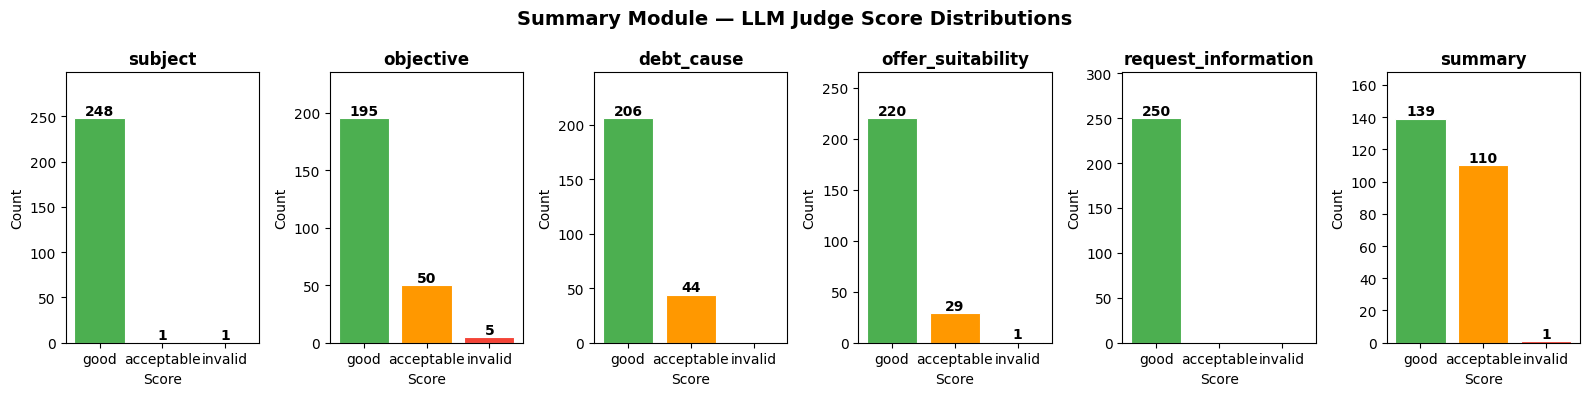

Chart saved → summary_score_distribution.png


In [19]:
fig, axes = plt.subplots(1, len(SCORE_FIELDS), figsize=(16, 4), sharey=False)
fig.suptitle("Summary Module — LLM Judge Score Distributions", fontsize=14, fontweight="bold")

for ax, f in zip(axes, SCORE_FIELDS):
    counts = df_results[f].value_counts().reindex(LABEL_ORDER, fill_value=0)
    colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
    bars   = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(val),
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )
    ax.set_ylim(0, max(counts.values) * 1.2 + 1)

plt.tight_layout()
plt.savefig("summary_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → summary_score_distribution.png")

### Score distributions by situation tested

In [20]:
situation_groups = df_results["situation_tested"].value_counts().index.tolist()
print("=" * 60)
print("SCORE DISTRIBUTIONS — by situation_tested")
print("=" * 60)

for sit in situation_groups:
    sub = df_results[df_results["situation_tested"] == sit]
    print(f"\n  situation: {sit}  (n={len(sub)})")
    for f in SCORE_FIELDS:
        counts = sub[f].value_counts()
        total  = counts.sum()
        print(f"    {f:25s}: ", end="")
        for lbl in LABEL_ORDER:
            n = counts.get(lbl, 0)
            print(f"{lbl}={n} ({n/total:.0%})  ", end="")
        print()

SCORE DISTRIBUTIONS — by situation_tested

  situation: ภาระหนี้หลายสถาบัน  (n=24)
    subject                  : good=24 (100%)  acceptable=0 (0%)  invalid=0 (0%)  
    objective                : good=21 (88%)  acceptable=3 (12%)  invalid=0 (0%)  
    debt_cause               : good=20 (83%)  acceptable=4 (17%)  invalid=0 (0%)  
    offer_suitability        : good=19 (79%)  acceptable=5 (21%)  invalid=0 (0%)  
    request_information      : good=24 (100%)  acceptable=0 (0%)  invalid=0 (0%)  
    summary                  : good=11 (46%)  acceptable=13 (54%)  invalid=0 (0%)  

  situation: มีค่าใช้จ่ายรักษาพยาบาล  (n=19)
    subject                  : good=19 (100%)  acceptable=0 (0%)  invalid=0 (0%)  
    objective                : good=15 (79%)  acceptable=4 (21%)  invalid=0 (0%)  
    debt_cause               : good=17 (89%)  acceptable=2 (11%)  invalid=0 (0%)  
    offer_suitability        : good=17 (89%)  acceptable=2 (11%)  invalid=0 (0%)  
    request_information      : good=19 (

/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_71436/2318590470.py:30: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_71436/2318590470.py:30: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_71436/2318590470.py:30: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_71436/2318590470.py:30: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_71436/2318590470.py:30: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000

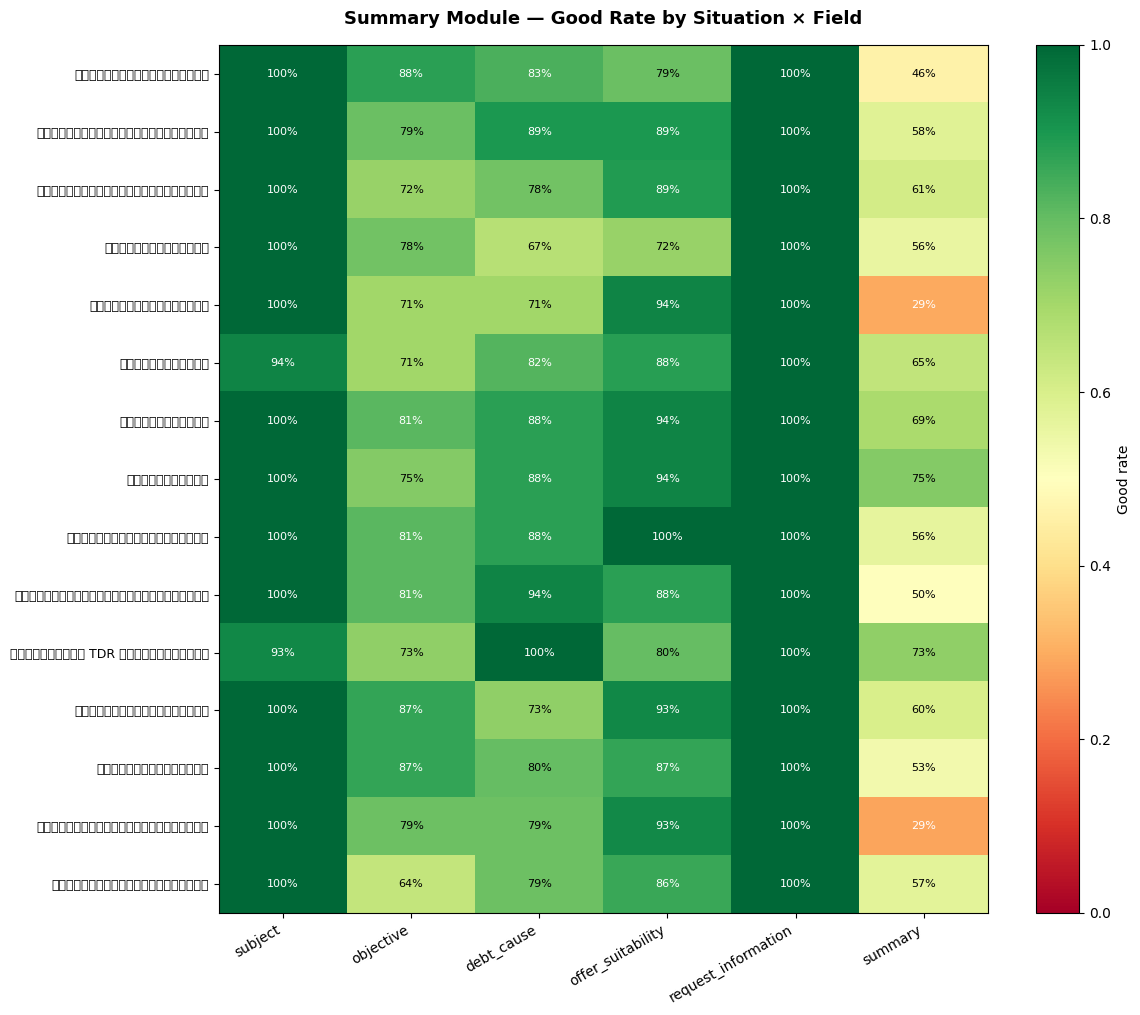

Chart saved → summary_score_by_situation.png


In [21]:
# Heatmap: good rate per situation × field
import numpy as np

good_rates = pd.DataFrame(index=situation_groups, columns=SCORE_FIELDS, dtype=float)
for sit in situation_groups:
    sub = df_results[df_results["situation_tested"] == sit]
    for f in SCORE_FIELDS:
        good_rates.loc[sit, f] = (sub[f] == "good").sum() / len(sub) if len(sub) else float("nan")

good_vals = good_rates.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 0.55 * len(situation_groups) + 2))
im = ax.imshow(good_vals, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(SCORE_FIELDS)))
ax.set_xticklabels(SCORE_FIELDS, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(situation_groups)))
ax.set_yticklabels(situation_groups, fontsize=9)

for i in range(len(situation_groups)):
    for j in range(len(SCORE_FIELDS)):
        val = good_vals[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if val < 0.4 or val > 0.8 else "black")

plt.colorbar(im, ax=ax, label="Good rate")
ax.set_title("Summary Module — Good Rate by Situation × Field",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("summary_score_by_situation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → summary_score_by_situation.png")

### Pass rate (good + acceptable) per field

In [22]:
print("=" * 60)
print("PASS RATE  (good + acceptable)")
print("=" * 60)

pass_rows = []
for f in SCORE_FIELDS:
    total   = df_results[f].notna().sum()
    n_good  = (df_results[f] == "good").sum()
    n_acc   = (df_results[f] == "acceptable").sum()
    n_inv   = (df_results[f] == "invalid").sum()
    pass_n  = n_good + n_acc
    pass_r  = pass_n / total if total else 0
    fail_r  = n_inv  / total if total else 0
    print(f"  {f:25s}: pass={pass_r:.1%}  (good={n_good/total:.1%}, acceptable={n_acc/total:.1%})  |  invalid={fail_r:.1%}")
    pass_rows.append({
        "field":      f,
        "total":      total,
        "good":       n_good,
        "acceptable": n_acc,
        "invalid":    n_inv,
        "pass_rate":  f"{pass_r:.1%}",
        "fail_rate":  f"{fail_r:.1%}",
    })

df_pass = pd.DataFrame(pass_rows)
df_pass

PASS RATE  (good + acceptable)
  subject                  : pass=99.6%  (good=99.2%, acceptable=0.4%)  |  invalid=0.4%
  objective                : pass=98.0%  (good=78.0%, acceptable=20.0%)  |  invalid=2.0%
  debt_cause               : pass=100.0%  (good=82.4%, acceptable=17.6%)  |  invalid=0.0%
  offer_suitability        : pass=99.6%  (good=88.0%, acceptable=11.6%)  |  invalid=0.4%
  request_information      : pass=100.0%  (good=100.0%, acceptable=0.0%)  |  invalid=0.0%
  summary                  : pass=99.6%  (good=55.6%, acceptable=44.0%)  |  invalid=0.4%


,field,total,good,acceptable,invalid,pass_rate,fail_rate
0,subject,250,248,1,1,99.6%,0.4%
1,objective,250,195,50,5,98.0%,2.0%
2,debt_cause,250,206,44,0,100.0%,0.0%
3,offer_suitability,250,220,29,1,99.6%,0.4%
4,request_information,250,250,0,0,100.0%,0.0%
5,summary,250,139,110,1,99.6%,0.4%


### Cases flagged `invalid` on any field

In [23]:
invalid_mask = (df_results[SCORE_FIELDS] == "invalid").any(axis=1)
df_invalid   = df_results[invalid_mask][
    ["testId", "situation_tested", "userMessage"] + SCORE_FIELDS
].reset_index(drop=True)

print(f"Cases with at least one 'invalid' score: {len(df_invalid)} / {len(df_results)}")
if len(df_invalid):
    print("\nBreakdown by situation_tested:")
    print(df_invalid["situation_tested"].value_counts().to_string())
    display(df_invalid)

Cases with at least one 'invalid' score: 7 / 250

Breakdown by situation_tested:
situation_tested
ขอเจ้าหน้าที่ติดต่อกลับ        1
ลูกค้าราชการ                   1
เปลี่ยนอาชีพ                   1
รับข้อเสนอ TDR ตามกำลังผ่อน    1
สอบถามเงื่อนไขก่อนตัดสินใจ     1
มีค่าใช้จ่ายรักษาพยาบาล        1
ค้างชำระระยะสั้น               1


,testId,situation_tested,userMessage,subject,objective,debt_cause,offer_suitability,request_information,summary
0,TC-0032,ขอเจ้าหน้าที่ติดต่อกลับ,The user select one of the offer provided by AI,good,invalid,acceptable,good,good,acceptable
1,TC-0043,ลูกค้าราชการ,The user select one of the offer provided by AI,invalid,good,acceptable,good,good,acceptable
2,TC-0078,เปลี่ยนอาชีพ,ดิฉันขอคุยกับเจ้าหน้าที่เพื่อหารือเรื่องแผนการ...,good,invalid,good,good,good,good
3,TC-0090,รับข้อเสนอ TDR ตามกำลังผ่อน,ขอคุยกับเจ้าหน้าที่หน่อยครับ,good,invalid,good,good,good,good
4,TC-0202,สอบถามเงื่อนไขก่อนตัดสินใจ,The user select one of the offer provided by AI,good,invalid,good,invalid,good,good
5,TC-0209,มีค่าใช้จ่ายรักษาพยาบาล,I lost income recently,good,good,good,good,good,invalid
6,TC-0225,ค้างชำระระยะสั้น,I need a lower monthly payment,good,invalid,good,good,good,acceptable


### Cases with all fields `good`

In [24]:
all_good_mask = (df_results[SCORE_FIELDS] == "good").all(axis=1)
df_all_good   = df_results[all_good_mask][
    ["testId", "situation_tested"] + SCORE_FIELDS
].reset_index(drop=True)

print(
    f"Cases with all fields 'good': {len(df_all_good)} / {len(df_results)}"
    f"  ({len(df_all_good)/len(df_results):.1%})"
)
if len(df_all_good):
    display(df_all_good)

Cases with all fields 'good': 90 / 250  (36.0%)


,testId,situation_tested,subject,objective,debt_cause,offer_suitability,request_information,summary
0,TC-0003,รายได้ลดลงชั่วคราว,good,good,good,good,good,good
1,TC-0008,ต้องการลดค่างวด,good,good,good,good,good,good
2,TC-0009,ต้องการขยายระยะเวลาผ่อน,good,good,good,good,good,good
3,TC-0013,ลูกค้าราชการ,good,good,good,good,good,good
4,TC-0015,สอบถามเงื่อนไขก่อนตัดสินใจ,good,good,good,good,good,good
...,...,...,...,...,...,...,...,...
85,TC-0222,ต้องการลดค่างวด,good,good,good,good,good,good
86,TC-0228,ลูกค้าราชการ,good,good,good,good,good,good
87,TC-0233,ลูกค้าราชการ,good,good,good,good,good,good
88,TC-0234,ค้างชำระสูง,good,good,good,good,good,good


### Demo: Invalid Cases — Full Input + Scored Fields

In [25]:
from IPython.display import display, HTML

RESULT_FIELDS = {
    "subject":             "result_subject",
    "objective":           "result_objective",
    "debt_cause":          "result_debt_cause",
    "offer_suitability":   "result_offer_suitability",
    "request_information": "result_request_information",
    "summary":             "result_summary",
}

SCORE_COLOR = {"good": "#2e7d32", "acceptable": "#e65100", "invalid": "#c62828"}
SCORE_BG    = {"good": "#e8f5e9", "acceptable": "#fff3e0", "invalid": "#ffebee"}

# Merge eval results with original input data
INPUT_COLS = [
    "testId", "preference", "maxPayment", "ageRange", "employmentType",
    "monthsAsCustomer", "dpd", "sumOsNCB",
    "installmentNCB_Y1", "installmentNCB_Y2", "installmentNCB_Y3",
]
df_full = df_results.merge(df[INPUT_COLS], on="testId", how="left")

invalid_mask = (df_full[SCORE_FIELDS] == "invalid").any(axis=1)
df_inv = df_full[invalid_mask].reset_index(drop=True)


def fmt(val):
    if pd.isna(val):
        return "—"
    try:
        return f"{float(val):,.2f}"
    except (ValueError, TypeError):
        return str(val)


def badge(score):
    c, bg = SCORE_COLOR.get(score, "#666"), SCORE_BG.get(score, "#f5f5f5")
    return (f'<span style="background:{bg};color:{c};border:1px solid {c};'
            f'border-radius:4px;padding:2px 10px;font-size:12px;font-weight:bold">{score}</span>')


def input_row(label, value):
    return (f'<tr><td style="padding:5px 10px;font-weight:bold;width:170px;'
            f'vertical-align:top;color:#444">{label}</td>'
            f'<td style="padding:5px 10px;line-height:1.6;white-space:pre-wrap">{value}</td></tr>')


def field_row(field, value, score):
    highlight = score == "invalid"
    row_bg    = "#fff5f5" if highlight else "#fafafa"
    border    = "border-left:3px solid #c62828" if highlight else "border-left:3px solid #eee"
    return (f'<tr style="border-bottom:1px solid #eee">'
            f'<td style="padding:7px 10px;font-weight:bold;width:170px;vertical-align:top">{field}</td>'
            f'<td style="padding:7px 10px;vertical-align:top;white-space:nowrap">{badge(score)}</td>'
            f'<td style="padding:7px 12px;background:{row_bg};{border};'
            f'line-height:1.6;white-space:pre-wrap">{value}</td></tr>')


cards = []
for _, row in df_inv.iterrows():
    invalid_fields = [f for f in SCORE_FIELDS if row[f] == "invalid"]

    ncb_line = (f'DPD {fmt(row["dpd"])} days &nbsp;·&nbsp; NCB {fmt(row["sumOsNCB"])} THB '
                f'&nbsp;·&nbsp; Max payment: {row["maxPayment"]}')
    inst_line = (f'Y1 {fmt(row["installmentNCB_Y1"])} / '
                 f'Y2 {fmt(row["installmentNCB_Y2"])} / '
                 f'Y3 {fmt(row["installmentNCB_Y3"])} THB/mo')

    input_rows = "".join([
        input_row("User Message",    str(row["userMessage"])),
        input_row("Age / Employment",f'{row["ageRange"]} &nbsp;·&nbsp; {row["employmentType"]}'),
        input_row("Months w/ bank",  fmt(row["monthsAsCustomer"])),
        input_row("DPD / NCB",       ncb_line),
        input_row("NCB Installments",inst_line),
        input_row("Preference",      str(row["preference"])),
        input_row("Narrative",       str(row["narrative"])),
        input_row("Offer",           str(row["offerReadableText"])),
    ])

    scored_rows = "".join(
        field_row(f, str(row[RESULT_FIELDS[f]]), row[f]) for f in SCORE_FIELDS
    )

    cards.append(f"""
<div style="border:2px solid #c62828;border-radius:8px;margin:24px 0;font-family:sans-serif;font-size:13.5px;box-shadow:0 2px 6px rgba(0,0,0,.08)">
  <div style="background:#c62828;color:white;padding:10px 16px;border-radius:6px 6px 0 0;display:flex;gap:16px;align-items:center">
    <strong style="font-size:15px">{row["testId"]}</strong>
    <span style="opacity:.85">{row["situation_tested"]}</span>
    <span style="margin-left:auto;font-size:12px">Invalid: {", ".join(invalid_fields)}</span>
  </div>

  <div style="padding:12px 16px;background:#f9f9f9;border-bottom:1px solid #ddd">
    <div style="font-weight:bold;color:#888;font-size:11px;letter-spacing:.08em;margin-bottom:6px">INPUT CONTEXT</div>
    <table style="width:100%;border-collapse:collapse">{input_rows}</table>
  </div>

  <div style="padding:12px 16px">
    <div style="font-weight:bold;color:#888;font-size:11px;letter-spacing:.08em;margin-bottom:6px">GENERATED FIELDS</div>
    <table style="width:100%;border-collapse:collapse">{scored_rows}</table>
  </div>
</div>
""")

display(HTML(f'<div style="max-width:960px">{"".join(cards)}</div>'))